# NPU Roofline Model - Measured from mul_bench Benchmark

This notebook measures the NPU roofline by **actually running the mul_bench benchmark** with different configurations.
The plot uses the measured throughput points and their empirical upper envelope rather than a theoretical peak model.

## Setup and Imports

In [1]:
import sys
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Dict
import subprocess

# Add parent directory to path for imports
sys.path.insert(0, str(Path.cwd()))

try:
    import pytest
    import aie.utils as aie_utils
    from iron.operators.mul_bench.op import MulBench
    from iron.operators.mul_bench.reference import generate_golden_reference
    from iron.common.test_utils import run_test
    AIE_AVAILABLE = True
except ImportError as e:
    print(f"Warning: Could not import AIE utilities: {e}")
    print("Some functionality may be limited. Will use stub data.")
    AIE_AVAILABLE = False

## BenchmarkPoint Dataclass and Helper Functions

In [21]:
@dataclass
class BenchmarkPoint:
    """Represents a single benchmark measurement"""
    size: int
    num_aie_columns: int
    R: int
    latency_us: float
    bandwidth_gbps: float
    
    @property
    def ai(self) -> float:
        """Calculate arithmetic intensity (FLOPs/Byte)"""
        # For mul_bench: R multiplications per element
        # Each repetition: c = c * x + alpha (FMA = 2 FLOPs)
        flops_per_element = self.R * 2  # 2 FLOPs per FMA, R FMAs
        
        # Memory: 2 inputs (bf16) + 1 output (bf16) = 3 * 2 bytes per element
        bytes_per_element = 2 * 2
        
        # Total operations and bytes
        total_flops = flops_per_element * self.size
        total_bytes = bytes_per_element * self.size
        
        return total_flops / total_bytes
    
    @property
    def gflops(self) -> float:
        """Calculate achieved GFLOPs/s"""
        # GFLOPs/s = (R * size * 2 FLOPs) / (latency_us * 1e-6)
        total_flops = self.R * self.size * 2
        return (total_flops / (self.latency_us * 1e-6)) / 1e9

## Run Actual mul_bench Benchmarks

This section runs the mul_bench operator with varying parameters:
- **R (repeat count)**: 1 to 2000 in steps of 50 - increases arithmetic intensity
- **Input size**: 1M elements (configurable)
- **AIE columns**: 8, 16 - tests scaling across columns

Each configuration is executed on actual NPU hardware, collecting:
- **Latency (us)**: Actual execution time
- **Bandwidth (GB/s)**: Memory bandwidth utilized
- **Arithmetic Intensity**: FLOPs/Byte ratio
- **Throughput (GFLOPs/s)**: Actual achieved performance

**Note**: For testing without hardware, set `use_stub=True` in the cell below.

In [18]:
def run_mul_bench_benchmark(use_stub=False) -> List[BenchmarkPoint]:
    """
    Run mul_bench with different configurations to collect actual performance data.
    Uses a fresh subprocess per benchmark point so the notebook can collect
    more than a small number of points without exhausting runtime contexts.
    """
    if use_stub:
        print("Using stub data (synthetic)...")
        points = []
        for size in [1 << 20]:
            for R in range(1, 4000, 50):
                for num_cols in [8]:
                    base_latency = size / (num_cols * 1e6)
                    latency_us = base_latency * (1.0 + 0.1 * np.random.random())
                    bandwidth_gbps = 100 + 50 * np.random.random()
                    points.append(
                        BenchmarkPoint(
                            size=size,
                            num_aie_columns=num_cols,
                            R=R,
                            latency_us=latency_us,
                            bandwidth_gbps=bandwidth_gbps,
                        )
                    )
        return points

    if not AIE_AVAILABLE:
        print("AIE utilities not available. Please ensure you're running in the IRON environment.")
        print("Falling back to stub data...")
        return run_mul_bench_benchmark(use_stub=True)

    print("Running actual mul_bench benchmarks on NPU...")
    points = []

    try:
        device = aie_utils.get_current_device()
        max_aie_columns = device.cols
        print(f"Device info: {max_aie_columns} AIE columns available\n")

        input_sizes = [1 << 20]
        R_values = list(range(1, 4000, 50))
        num_columns_list = [8]

        total_tests = len(input_sizes) * len(R_values) * len(num_columns_list)
        test_count = 0

        benchmark_script = """
import json
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

from iron.operators.mul_bench.op import MulBench
from iron.operators.mul_bench.reference import generate_golden_reference
from iron.common.test_utils import run_test

input_length = int(sys.argv[1])
num_aie_columns = int(sys.argv[2])
R = int(sys.argv[3])
tile_size = int(sys.argv[4])

golden_ref = generate_golden_reference(input_length=input_length, R=R)
operator = MulBench(
    size=input_length,
    tile_size=tile_size,
    num_aie_columns=num_aie_columns,
    num_channels=2,
    R=R,
    context=None,
)

input_buffers = {"input1": golden_ref["A"]}
output_buffers = {"output": golden_ref["C"]}
errors, latency_us, bandwidth_gbps = run_test(
    operator,
    input_buffers,
    output_buffers,
    rel_tol=0.04,
    abs_tol=1e-6,
)
print(json.dumps({"latency_us": latency_us, "bandwidth_gbps": bandwidth_gbps}))
"""

        for input_length in input_sizes:
            for num_aie_columns in num_columns_list:
                if num_aie_columns > max_aie_columns:
                    print(f"Skipping {num_aie_columns} columns (exceeds device max)")
                    continue

                tile_size = 8192

                for R in R_values:
                    test_count += 1
                    print(
                        f"[{test_count}/{total_tests}] Running: size={input_length}, "
                        f"columns={num_aie_columns}, R={R}...",
                        end=' ',
                        flush=True,
                    )

                    try:
                        result = subprocess.run(
                            [
                                sys.executable,
                                "-c",
                                benchmark_script,
                                str(input_length),
                                str(num_aie_columns),
                                str(R),
                                str(tile_size),
                            ],
                            cwd=str(Path.cwd()),
                            capture_output=True,
                            text=True,
                            check=True,
                        )
                        measured = json.loads(result.stdout.strip().splitlines()[-1])
                        latency_us = float(measured["latency_us"])
                        bandwidth_gbps = float(measured["bandwidth_gbps"])
                        point = BenchmarkPoint(
                            size=input_length,
                            num_aie_columns=num_aie_columns,
                            R=R,
                            latency_us=latency_us,
                            bandwidth_gbps=bandwidth_gbps,
                        )
                        points.append(point)
                        print(f"✓ AI={point.ai:.4f}, GFLOPs/s={point.gflops:.2f}")

                    except Exception as e:
                        message = str(e)
                        stderr = getattr(e, "stderr", "") or ""
                        combined = f"{message}\n{stderr}"
                        print(f"✗ Error: {combined[:120]}")
                        continue

        print(f"\n✓ Benchmark complete! Collected {len(points)} data points.")
        return points

    except Exception as e:
        print(f"Error running benchmarks: {e}")
        print("Falling back to stub data...")
        return run_mul_bench_benchmark(use_stub=True)


# Run benchmarks (set use_stub=True to use synthetic data for testing)
points = run_mul_bench_benchmark(use_stub=False)
print(f"\nTotal benchmark points collected: {len(points)}")

Running actual mul_bench benchmarks on NPU...
Device info: 8 AIE columns available

[1/80] Running: size=1048576, columns=8, R=1... ✓ AI=0.3333, GFLOPs/s=11.07
[2/80] Running: size=1048576, columns=8, R=51... ✓ AI=17.0000, GFLOPs/s=616.54
[3/80] Running: size=1048576, columns=8, R=101... ✓ AI=33.6667, GFLOPs/s=1135.96
[4/80] Running: size=1048576, columns=8, R=151... ✓ AI=50.3333, GFLOPs/s=1478.02
[5/80] Running: size=1048576, columns=8, R=201... ✓ AI=67.0000, GFLOPs/s=1754.96
[6/80] Running: size=1048576, columns=8, R=251... ✓ AI=83.6667, GFLOPs/s=1913.09
[7/80] Running: size=1048576, columns=8, R=301... ✓ AI=100.3333, GFLOPs/s=2436.87
[8/80] Running: size=1048576, columns=8, R=351... ✓ AI=117.0000, GFLOPs/s=2787.87
[9/80] Running: size=1048576, columns=8, R=401... ✓ AI=133.6667, GFLOPs/s=3076.21
[10/80] Running: size=1048576, columns=8, R=451... ✓ AI=150.3333, GFLOPs/s=3056.21
[11/80] Running: size=1048576, columns=8, R=501... ✓ AI=167.0000, GFLOPs/s=3184.42
[12/80] Running: size=104

## Data Analysis

In [19]:
# Extract data from collected benchmarks
ais = np.array([p.ai for p in points])
gflops = np.array([p.gflops for p in points])
rs = np.array([p.R for p in points])

if len(points) > 0:
    print("Benchmark Summary:")
    print(f"  Total points: {len(points)}")
    print(f"  Arithmetic Intensity range: {ais.min():.4f} - {ais.max():.4f} FLOPs/Byte")
    print(f"  Throughput range: {gflops.min():.2f} - {gflops.max():.2f} GFLOPs/s")
    print(f"  R values tested: {np.unique(rs)}")
else:
    print("No benchmark data collected. Please run the benchmark cell above first.")

Benchmark Summary:
  Total points: 80
  Arithmetic Intensity range: 0.3333 - 1317.0000 FLOPs/Byte
  Throughput range: 11.07 - 6476.64 GFLOPs/s
  R values tested: [   1   51  101  151  201  251  301  351  401  451  501  551  601  651
  701  751  801  851  901  951 1001 1051 1101 1151 1201 1251 1301 1351
 1401 1451 1501 1551 1601 1651 1701 1751 1801 1851 1901 1951 2001 2051
 2101 2151 2201 2251 2301 2351 2401 2451 2501 2551 2601 2651 2701 2751
 2801 2851 2901 2951 3001 3051 3101 3151 3201 3251 3301 3351 3401 3451
 3501 3551 3601 3651 3701 3751 3801 3851 3901 3951]


## Roofline Visualization

Measured roofline plot saved to: npu_mul_bench_measured_roofline.png


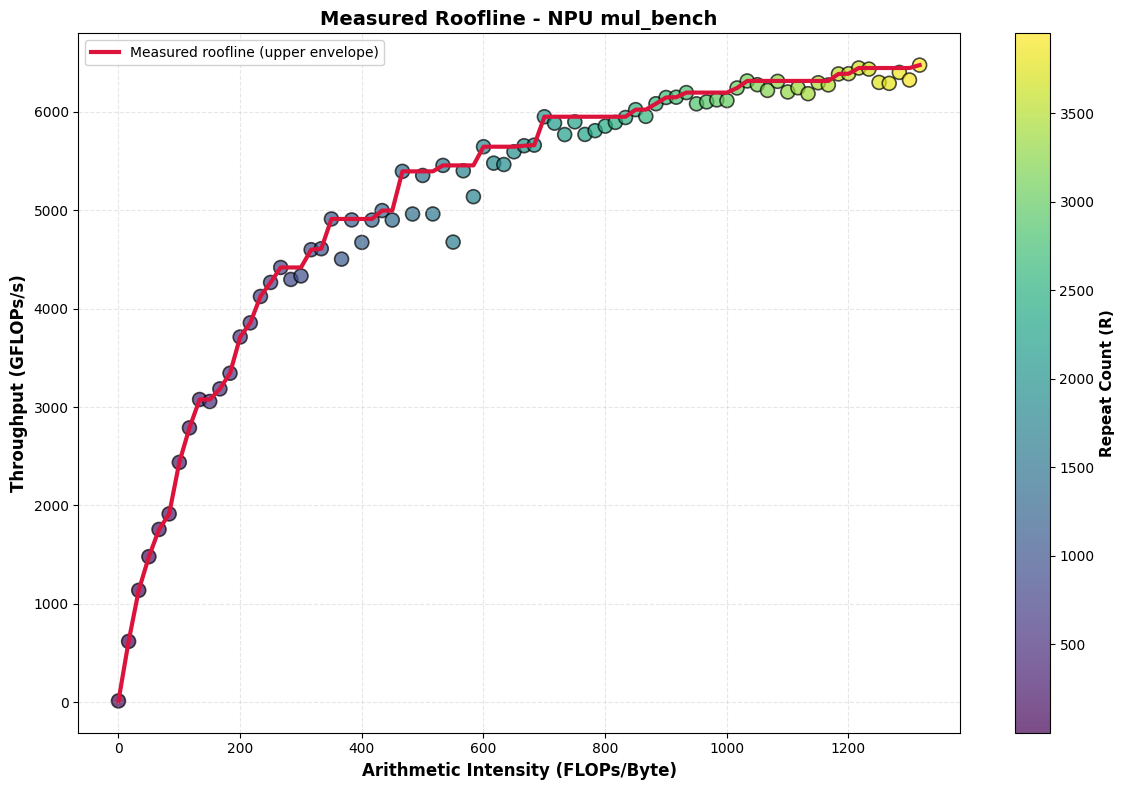

In [20]:
# Build an empirical roofline from the measured points, not from peak assumptions.
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    ais,
    gflops,
    s=100,
    alpha=0.7,
    c=rs,
    cmap='viridis',
    edgecolors='black',
    linewidth=1.2,
)

order = np.argsort(ais)
ai_sorted = ais[order]
gflops_sorted = gflops[order]
measured_roofline = np.maximum.accumulate(gflops_sorted)

ax.plot(
    ai_sorted,
    measured_roofline,
    color='crimson',
    linewidth=3,
    label='Measured roofline (upper envelope)',
    zorder=5,
)


ax.set_xlabel('Arithmetic Intensity (FLOPs/Byte)', fontsize=12, fontweight='bold')
ax.set_ylabel('Throughput (GFLOPs/s)', fontsize=12, fontweight='bold')
ax.set_title('Measured Roofline - NPU mul_bench', fontsize=14, fontweight='bold')
ax.grid(True, which='both', alpha=0.3, linestyle='--')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Repeat Count (R)', fontsize=11, fontweight='bold')

ax.legend(loc='upper left', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig('npu_mul_bench_measured_roofline.png', dpi=300, bbox_inches='tight')
print('Measured roofline plot saved to: npu_mul_bench_measured_roofline.png')
plt.show()

## Performance Metrics by Configuration

In [11]:
# Analyze performance by different parameters
import pandas as pd

# Create DataFrame from points
df = pd.DataFrame([
    {
        'size': p.size,
        'num_aie_columns': p.num_aie_columns,
        'R': p.R,
        'latency_us': p.latency_us,
        'bandwidth_gbps': p.bandwidth_gbps,
        'ai': p.ai,
        'gflops': p.gflops
    }
    for p in points
])

# Display sample of data
print("Sample of benchmark data:")
print(df.head(10).to_string(index=False))

# Performance by R value
print("\nAverage performance by R value:")
print(df.groupby('R')[['ai', 'gflops']].mean().to_string())

# Performance by column count
print("\nAverage performance by AIE column count:")
print(df.groupby('num_aie_columns')[['ai', 'gflops']].mean().to_string())

Sample of benchmark data:
   size  num_aie_columns   R  latency_us  bandwidth_gbps         ai      gflops
1048576                8   1     181.900       23.058296   0.333333   11.529148
1048576                8  51     182.622       22.967134  17.000000  585.661925
1048576                8 101     187.250       22.399487  33.666667 1131.174109
1048576                8 151     213.335       19.660646  50.333333 1484.378803
1048576                8 201     232.539       18.036992  67.000000 1812.717660
1048576                8 251     217.833       19.254677  83.666667 2416.461932
1048576                8 301     312.076       13.440008 100.333333 2022.721235
1048576                8 351     277.928       15.091333 117.000000 2648.528943
1048576                8 401     283.067       14.817354 133.666667 2970.879516
1048576                8 451     281.405       14.904867 150.333333 3361.047430

Average performance by R value:
              ai       gflops
R                            
1

## Save Benchmark Data

In [12]:
# Save to JSON
roofline_envelope = np.maximum.accumulate(gflops[np.argsort(ais)]) if len(points) > 0 else np.array([])

data = {
    'points': [
        {
            'size': p.size,
            'num_aie_columns': p.num_aie_columns,
            'R': p.R,
            'latency_us': p.latency_us,
            'bandwidth_gbps': p.bandwidth_gbps,
            'arithmetic_intensity': p.ai,
            'achieved_gflops': p.gflops,
        }
        for p in points
    ],
    'summary': {
        'num_points': len(points),
        'min_ai': float(ais.min()) if len(points) > 0 else 0.0,
        'max_ai': float(ais.max()) if len(points) > 0 else 0.0,
        'min_gflops': float(gflops.min()) if len(points) > 0 else 0.0,
        'max_gflops': float(gflops.max()) if len(points) > 0 else 0.0,
        'measured_roofline_peak_gflops': float(roofline_envelope.max()) if len(roofline_envelope) > 0 else 0.0,
    },
}

with open('mul_bench_roofline_data.json', 'w') as f:
    json.dump(data, f, indent=2)

print('Benchmark data saved to: mul_bench_roofline_data.json')

df.to_csv('mul_bench_roofline_data.csv', index=False)
print('Benchmark data saved to: mul_bench_roofline_data.csv')

Benchmark data saved to: mul_bench_roofline_data.json
Benchmark data saved to: mul_bench_roofline_data.csv


## Analysis and Insights

In [8]:
# Identify measured performance characteristics
print('Performance Analysis:')
print('=' * 60)

measured_peak_gflops = df['gflops'].max()
peak_point = df.loc[df['gflops'].idxmax()]

print(f"\nMeasured peak throughput: {measured_peak_gflops:.2f} GFLOPs/s")
print(
    f"  At AI={peak_point['ai']:.4f}, R={int(peak_point['R'])}, "
    f"columns={int(peak_point['num_aie_columns'])}, size={int(peak_point['size'])}"
)

print(f"\nMeasured AI range: {df['ai'].min():.4f} - {df['ai'].max():.4f} FLOPs/Byte")
print(f"Measured throughput range: {df['gflops'].min():.2f} - {df['gflops'].max():.2f} GFLOPs/s")
print(f"Unique R values tested: {sorted(df['R'].unique().tolist())}")

# Show the top measured points as the empirical roofline frontier
frontier = df.sort_values('ai').copy()
frontier['measured_frontier_gflops'] = frontier['gflops'].cummax()
print('\nEmpirical roofline frontier (first 10 points):')
print(frontier[['ai', 'gflops', 'measured_frontier_gflops']].head(10).to_string(index=False))

Performance Analysis:

Measured peak throughput: 5688.55 GFLOPs/s
  At AI=617.0000, R=1851, columns=8, size=1048576

Measured AI range: 0.3333 - 650.3333 FLOPs/Byte
Measured throughput range: 11.53 - 5688.55 GFLOPs/s
Unique R values tested: [1, 51, 101, 151, 201, 251, 301, 351, 401, 451, 501, 551, 601, 651, 701, 751, 801, 851, 901, 951, 1001, 1051, 1101, 1151, 1201, 1251, 1301, 1351, 1401, 1451, 1501, 1551, 1601, 1651, 1701, 1751, 1801, 1851, 1901, 1951]

Empirical roofline frontier (first 10 points):
        ai      gflops  measured_frontier_gflops
  0.333333   11.529148                 11.529148
 17.000000  585.661925                585.661925
 33.666667 1131.174109               1131.174109
 50.333333 1484.378803               1484.378803
 67.000000 1812.717660               1812.717660
 83.666667 2416.461932               2416.461932
100.333333 2022.721235               2416.461932
117.000000 2648.528943               2648.528943
133.666667 2970.879516               2970.879516
150